# **9. Fairness Analysis Across Demographic Groups**

**Inputs from Day 8:**
- Tuned XGBoost (Run 2: max_depth=13), Platt-calibrated on `X_val`
- Operating threshold = derived via Fbeta=0.3 precision-weighted on `X_val` (self-contained in this notebook)
- Val confusion matrix @THRESH: TN 143,192 / FP 24,410 / FN 130,934 / TP 362,663 → FNR 26.5%
- Test confusion matrix @THRESH: TN 357,918 / FP 61,087 / FN 326,132 / TP 907,860 → FNR 26.4%
- ~457,000 actually-approved applicants (val+test combined) predicted as "deny" at the business threshold — the population this step characterizes by demographic group
- Day 8 finding: `tract_minority_population_percent` ranks #7 by SHAP (vs #50 by XGBoost gain), with mean SHAP contribution varying by `derived_race`

**Honest scope note:** this step *measures and reports* subgroup disparities in the trained model's error rates and calibration. It does **not** implement a fairness-constrained optimizer or retrain the model to close any gaps found — that is a deliberate, stated limitation of the project. The earlier "Day 3" regression-adjusted analysis was never executed; Day 9 is about the *model's* subgroup error rates, which is a related but different question from whether the raw historical decisions were disparate after controls.


## **Step 0 — Setup, methodology decisions and primary subset construction**

Reapplies Day 2's exclusion rule (`Joint`, `*_Not Available`, `Free Form Text Only` excluded from the primary comparison per demographic dimension, with sizes reported separately). Protocol: `X_val` is the working partition for Steps 1-5 (iterative); `X_test` gets exactly one confirmatory look in Step 6. Evaluation at both the default 0.5 threshold and the business threshold. Small-sample rule: flag any group with n < 500 in the evaluation subset.


In [1]:
import os, time, warnings
from pathlib import Path
import numpy as np, pandas as pd
import joblib, xgboost as xgb
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                             recall_score, f1_score, confusion_matrix, precision_recall_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
%matplotlib inline
import matplotlib.pyplot as plt
import shap
warnings.filterwarnings('ignore')

ROOT = Path('/Volumes/Mitul/Projects/home-mortage-approval-predictor')
M = ROOT / 'data' / 'processed' / 'modelling'
ART = ROOT / 'artifacts'
FIG = ROOT / 'figures' / 'day9'
FIG.mkdir(parents=True, exist_ok=True)
MARK = ROOT / 'markdown'
MARK.mkdir(exist_ok=True)

model = joblib.load(ART / 'hmda_tuned_xgboost.pkl')
print('loaded model:', type(model).__name__)

feat = pd.read_csv(M / 'day7_model_features.csv')
FEATURES = feat['feature'].tolist()
assert len(FEATURES) == 78
Xval = pd.read_parquet(M / 'X_val.parquet').astype(np.float32)
yval = pd.read_parquet(M / 'y_val.parquet')['approved'].astype('int8').values
Xtest = pd.read_parquet(M / 'X_test.parquet').astype(np.float32)
ytest = pd.read_parquet(M / 'y_test.parquet')['approved'].astype('int8').values
Xv, Xt = Xval[FEATURES].values, Xtest[FEATURES].values
assert list(Xval[FEATURES].columns) == FEATURES, 'feature order mismatch'

val_demo = pd.read_parquet(M / 'val_demographics_lookup.parquet')
test_demo = pd.read_parquet(M / 'test_demographics_lookup.parquet')
assert len(val_demo) == len(Xval) and len(test_demo) == len(Xtest), 'demographics alignment'

EXCLUSIONS = {
    'derived_race': ['Joint', 'Race Not Available', 'Free Form Text Only'],
    'derived_ethnicity': ['Joint', 'Ethnicity Not Available', 'Free Form Text Only'],
    'derived_sex': ['Joint', 'Sex Not Available'],
}
SMALL_N = 500
DIMS = ['derived_race', 'derived_ethnicity', 'derived_sex']

def primary_mask(demo, dim):
    return ~demo[dim].isin(EXCLUSIONS[dim])

Xv_p = {dim: Xv[primary_mask(val_demo, dim)] for dim in DIMS}
yv_p = {dim: yval[primary_mask(val_demo, dim)] for dim in DIMS}
pcv_p = {dim: None for dim in DIMS}
demop_p = {dim: val_demo.loc[primary_mask(val_demo, dim)].reset_index(drop=True) for dim in DIMS}
for dim in DIMS:
    print(dim, 'primary n:', int(primary_mask(val_demo, dim).sum()),
          '| excluded:', int((~primary_mask(val_demo, dim)).sum()),
          '| groups:', list(demop_p[dim][dim].unique()))


/Volumes/Mitul/Projects/home-mortage-approval-predictor/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded model: XGBClassifier
derived_race primary n: 530805 | excluded: 130394 | groups: ['White', 'Black or African American', 'American Indian or Alaska Native', '2 or more minority races', 'Native Hawaiian or Other Pacific Islander', 'Asian']
derived_ethnicity primary n: 539278 | excluded: 121921 | groups: ['Not Hispanic or Latino', 'Hispanic or Latino']
derived_sex primary n: 389774 | excluded: 271425 | groups: ['Female', 'Male']


## **Recompute Platt calibration and the business threshold (self-contained)**

Raw scores come off the loaded model (`scale_pos_weight` distorts probabilities), so a Platt (logistic) scaler is fit on `X_val` only and used for the business threshold and all calibrated outputs. The **raw model is retained for SHAP** (logistic calibration is monotonic, preserving ranking and SHAP additivity).


In [10]:
def raw_proba(X):
    if isinstance(model, xgb.Booster):
        return model.predict(xgb.DMatrix(X))
    return model.predict_proba(X)[:, 1]

p_val = raw_proba(Xv)
p_test = raw_proba(Xt)
print('REPRODUCED val  ROC-AUC=%.4f PR-AUC=%.4f' % (roc_auc_score(yval, p_val), average_precision_score(yval, p_val)))
print('REPRODUCED test ROC-AUC=%.4f PR-AUC=%.4f' % (roc_auc_score(ytest, p_test), average_precision_score(ytest, p_test)))

cal = LogisticRegression()
cal.fit(p_val.reshape(-1, 1), yval)
pc_val = cal.predict_proba(p_val.reshape(-1, 1))[:, 1]
pc_test = cal.predict_proba(p_test.reshape(-1, 1))[:, 1]

BETA = 0.3
prec, rec, thr = precision_recall_curve(yval, pc_val)
fb = (1 + BETA**2) * prec[:-1] * rec[:-1] / (BETA**2 * prec[:-1] + rec[:-1] + 1e-12)
fb_thr = thr[np.argmax(fb)]
f1_thr = thr[np.argmax(2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-12))]
THRESH = fb_thr
print('Fbeta(B=%.1f) threshold = %.4f [CHOSEN]' % (BETA, THRESH))
print('F1-optimal threshold    = %.4f (comparison only)' % f1_thr)
print('FN count val+test at THRESH:', int(((yval==1)&(pc_val<THRESH)).sum() + ((ytest==1)&(pc_test<THRESH)).sum()))
pcv_p = {dim: pc_val[primary_mask(val_demo, dim)] for dim in DIMS}
pc_test_p = {dim: pc_test[primary_mask(test_demo, dim)] for dim in DIMS}


REPRODUCED val  ROC-AUC=0.8930 PR-AUC=0.9531
REPRODUCED test ROC-AUC=0.8933 PR-AUC=0.9532
Fbeta(B=0.3) threshold = 0.8582 [CHOSEN]
F1-optimal threshold    = 0.3454 (comparison only)
FN count val+test at THRESH: 457066


## **Step 1 — Subgroup confusion-matrix metrics**

For `derived_race`, `derived_ethnicity`, and `derived_sex` separately: TPR, FPR, FNR, precision, recall, F1, and group size `n`, at **both** thresholds (0.5 and THRESH), on the primary `X_val` subset. FNR is reported with the same visual weight as every other metric — it is the fair-lending-sensitive metric. FPR is labeled as the over-approval / portfolio-risk metric.


In [3]:
def subgroup_metrics(X, y, p, demo, dim, thresh):
    mask = ~demo[dim].isin(EXCLUSIONS[dim])
    Xs, ys, ps = X[mask], y[mask], p[mask]
    groups = demo.loc[mask, dim]
    rows = []
    for g in sorted(groups.unique()):
        idx = groups == g
        yt, pt = ys[idx], ps[idx]
        pred = (pt >= thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(yt, pred).ravel()
        tpr = tp/(tp+fn) if (tp+fn)>0 else np.nan
        fpr = fp/(fp+tn) if (fp+tn)>0 else np.nan
        fnr = fn/(fn+tp) if (fn+tp)>0 else np.nan
        rows.append(dict(group=g, n=len(yt), TPR=tpr, FPR=fpr, FNR=fnr,
                         precision=precision_score(yt, pred, zero_division=0),
                         recall=recall_score(yt, pred, zero_division=0),
                         F1=f1_score(yt, pred, zero_division=0)))
    return pd.DataFrame(rows)

RES = {}
for dim in DIMS:
    RES[dim] = {0.5: subgroup_metrics(Xv, yval, pc_val, val_demo, dim, 0.5),
                THRESH: subgroup_metrics(Xv, yval, pc_val, val_demo, dim, THRESH)}
    for t, df in RES[dim].items():
        df['small'] = df['n'] < SMALL_N
        print('==== %s @ %.4f ====' % (dim, t))
        print(df.round(4).to_string(index=False))
        print()


==== derived_race @ 0.5000 ====
                                    group      n    TPR    FPR    FNR  precision  recall     F1  small
                 2 or more minority races   1836 0.9468 0.3354 0.0532     0.8877  0.9468 0.9163  False
         American Indian or Alaska Native   6548 0.9401 0.3525 0.0599     0.8820  0.9401 0.9101  False
                                    Asian  23806 0.9355 0.3383 0.0645     0.8938  0.9355 0.9142  False
                Black or African American  67980 0.9380 0.3465 0.0620     0.8882  0.9380 0.9124  False
Native Hawaiian or Other Pacific Islander   1891 0.9343 0.3368 0.0657     0.8921  0.9343 0.9127  False
                                    White 428744 0.9361 0.3465 0.0639     0.8882  0.9361 0.9115  False

==== derived_race @ 0.8582 ====
                                    group      n    TPR    FPR    FNR  precision  recall     F1  small
                 2 or more minority races   1836 0.7413 0.1201 0.2587     0.9453  0.7413 0.8310  False
        

## **Step 2 — Quantify the disparities**

For each metric, the gap between the highest-scoring and lowest-scoring group is computed and compared against the small-sample flag (are the largest gaps from well-populated groups or from the smallest?). Most importantly, the **0.5-threshold gaps are compared directly against the 0.858-threshold gaps** on FNR — does the precision-weighted business threshold shrink, widen, or leave subgroup disparities unchanged?


In [4]:
def compute_gaps(df, dim, thresh):
    gaps = []
    for metric in ['TPR','FPR','FNR','precision','recall','F1']:
        arr = df[metric].values
        hi = int(np.argmax(arr)); lo = int(np.argmin(arr))
        gaps.append(dict(metric=metric, dim=dim, thresh=round(thresh,4),
                         high_group=df.loc[hi,'group'], low_group=df.loc[lo,'group'],
                         high_val=arr[hi], low_val=arr[lo], gap=arr[hi]-arr[lo],
                         small_sample=(df.loc[hi,'n'] < SMALL_N) or (df.loc[lo,'n'] < SMALL_N)))
    return pd.DataFrame(gaps)

GAPS = {}
for dim in DIMS:
    GAPS[dim] = {0.5: compute_gaps(RES[dim][0.5], dim, 0.5),
                 THRESH: compute_gaps(RES[dim][THRESH], dim, THRESH)}

print('=== FNR gap: highest vs lowest group, per dimension, both thresholds ===')
print('(positive gap = highest-group FNR > lowest-group FNR)')
for dim in DIMS:
    for t in [0.5, THRESH]:
        row = GAPS[dim][t].query('metric=="FNR"').iloc[0]
        print('%-15s @%.4f  FNR gap=%.4f  high=%s low=%s  small_sample=%s' %
              (dim, t, row['gap'], row['high_group'], row['low_group'], row['small_sample']))

print()
print('=== 0.5 vs 0.858 verdict on FNR disparity ===')
for dim in DIMS:
    g05 = GAPS[dim][0.5].query('metric=="FNR"').gap.values[0]
    gthr = GAPS[dim][THRESH].query('metric=="FNR"').gap.values[0]
    verdict = 'helped (FNR gap shrank)' if abs(gthr) < abs(g05) else 'widened (FNR gap grew)'
    print('%-15s FNR gap @0.5=%.4f @%.4f=%.4f -> %s' % (dim, g05, THRESH, gthr, verdict))


=== FNR gap: highest vs lowest group, per dimension, both thresholds ===
(positive gap = highest-group FNR > lowest-group FNR)
derived_race    @0.5000  FNR gap=0.0125  high=Native Hawaiian or Other Pacific Islander low=2 or more minority races  small_sample=False
derived_race    @0.8582  FNR gap=0.0064  high=White low=2 or more minority races  small_sample=False
derived_ethnicity @0.5000  FNR gap=0.0012  high=Hispanic or Latino low=Not Hispanic or Latino  small_sample=False
derived_ethnicity @0.8582  FNR gap=0.0057  high=Hispanic or Latino low=Not Hispanic or Latino  small_sample=False
derived_sex     @0.5000  FNR gap=0.0012  high=Female low=Male  small_sample=False
derived_sex     @0.8582  FNR gap=0.0028  high=Female low=Male  small_sample=False

=== 0.5 vs 0.858 verdict on FNR disparity ===
derived_race    FNR gap @0.5=0.0125 @0.8582=0.0064 -> helped (FNR gap shrank)
derived_ethnicity FNR gap @0.5=0.0012 @0.8582=0.0057 -> widened (FNR gap grew)
derived_sex     FNR gap @0.5=0.0012 @0.

## **Step 3 — Calibration by group**

Separate reliability diagrams (same method as Day 8's global one) for the calibrated model's output, split by `derived_race` and `derived_sex`. Groups with n < 200 are skipped to avoid unstable binning. This checks whether Day 8's globally-fit Platt scaling holds up equally well within each subgroup.


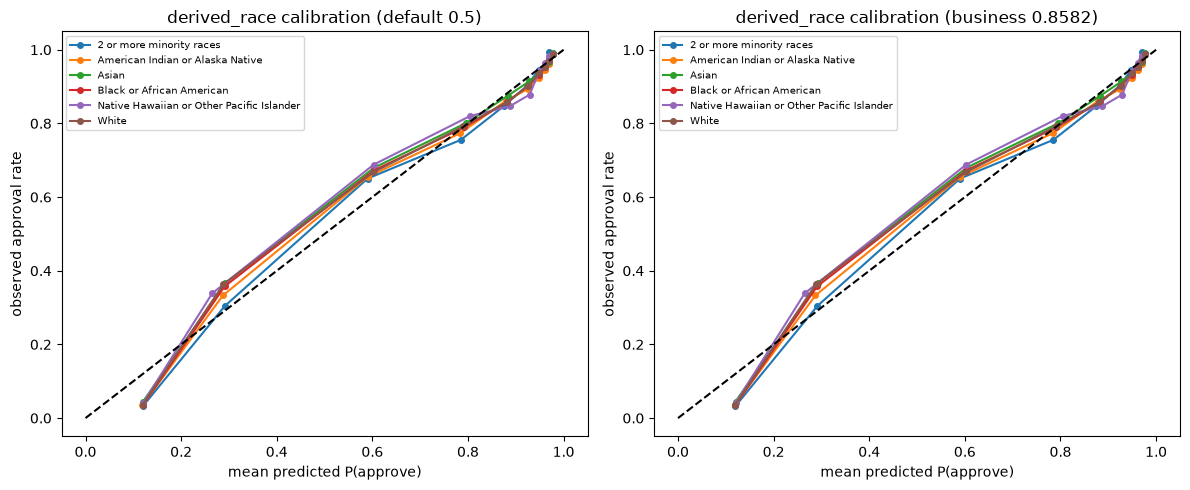

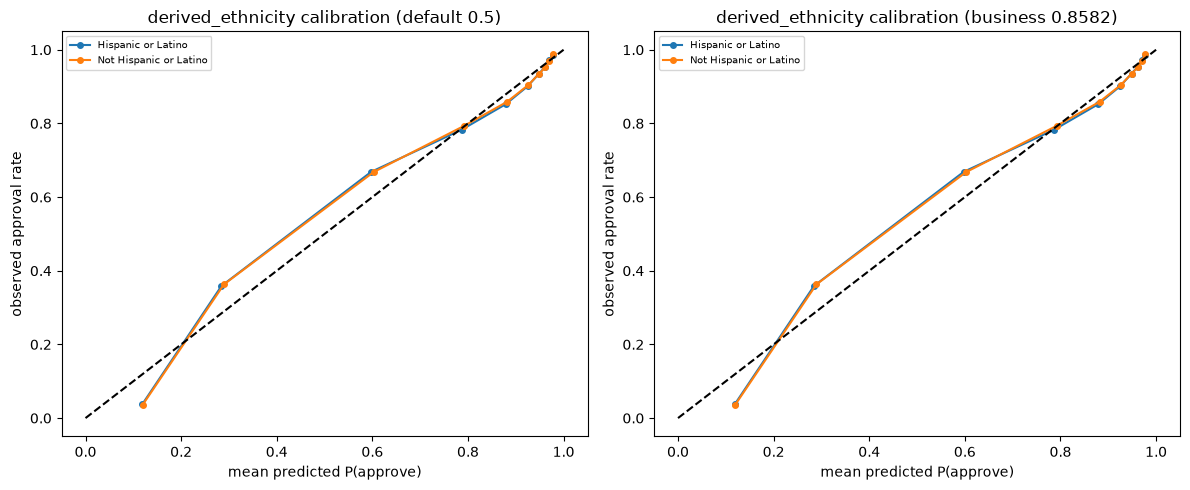

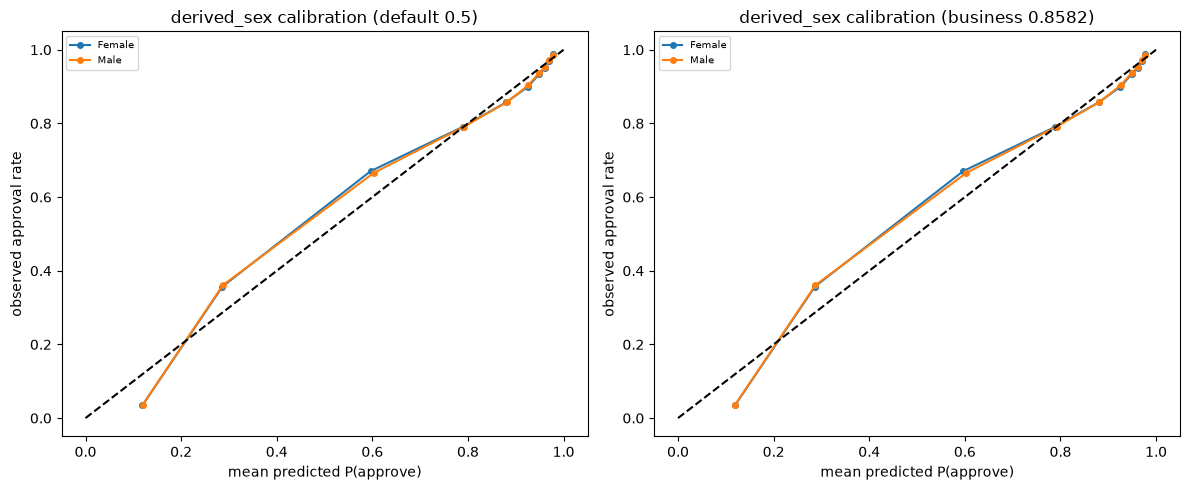

In [5]:
for dim in DIMS:
    groups = sorted(demop_p[dim][dim].unique())
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (thresh, label, pc_p) in zip(axes,
        [(0.5, 'default 0.5', pcv_p[dim]), (THRESH, 'business %.4f' % THRESH, pcv_p[dim])]):
        for g in groups:
            idx = demop_p[dim][dim] == g
            if idx.sum() < 200: continue
            yt = yv_p[dim][idx]; pt = pc_p[idx]
            try:
                frac, mean = calibration_curve(yt, pt, n_bins=10, strategy='quantile')
                ax.plot(mean, frac, 'o-', label=g, ms=4)
            except Exception:
                pass
        ax.plot([0,1],[0,1],'k--')
        ax.set_xlabel('mean predicted P(approve)'); ax.set_ylabel('observed approval rate')
        ax.set_title('%s calibration (%s)' % (dim, label)); ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()


## **Step 4 — Tie back the Day 8 race-proxy SHAP finding**

Recomputes the `TreeExplainer` on the raw model over a stratified 50k sample from `X_val` (aligned positionally with the demographics), then takes the `tract_minority_population_percent` SHAP column grouped by `derived_race` — the visual, model-free counterpart to Day 8's finding. This is placed side by side with Step 1-2's actual error-rate disparities to see whether the SHAP signal predicts the measured outcome disparity.


SHAP done | sv shape (50000, 78) | expected_value -0.00079
                                             mean  abs_mean  count
derived_race                                                      
American Indian or Alaska Native           0.0098    0.1432    511
White                                      0.0108    0.1469  32346
Black or African American                  0.0116    0.1469   5210
Asian                                      0.0168    0.1474   1845
Native Hawaiian or Other Pacific Islander  0.0188    0.1442    149
2 or more minority races                   0.0195    0.1513    162


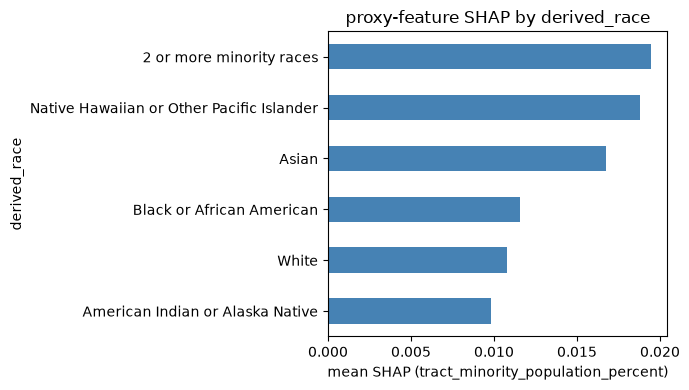

positive mean => feature pushes group toward approval; negative => toward denial.
Tie-back: compare this SHAP ranking to the FNR ranking from Step 2 to see whether the proxy signal lines up with measured outcome disparity.


In [6]:
N_EXPLAIN = 50000
rng = np.random.RandomState(42)
pos = rng.choice(len(Xv), size=N_EXPLAIN, replace=False)
X_explain = Xv[pos]
demo_explain = val_demo.iloc[pos].reset_index(drop=True)
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X_explain)
if isinstance(sv, list): sv = sv[1]
ev = float(np.asarray(explainer.expected_value)[1]) if np.asarray(explainer.expected_value).size > 1 else float(explainer.expected_value)
print('SHAP done | sv shape %s | expected_value %.5f' % (sv.shape, ev))

j = FEATURES.index('tract_minority_population_percent')
proxy_sv = sv[:, j]
demo_explain['proxy_sv'] = proxy_sv
race_mask = ~demo_explain['derived_race'].isin(EXCLUSIONS['derived_race'])
mean_sv = demo_explain.loc[race_mask].groupby('derived_race')['proxy_sv'].mean()
abs_sv = demo_explain.loc[race_mask].groupby('derived_race')['proxy_sv'].apply(lambda s: np.abs(s).mean())
cnt = demo_explain.loc[race_mask].groupby('derived_race')['proxy_sv'].count()
grp = pd.concat([mean_sv, abs_sv, cnt], axis=1, keys=['mean','abs_mean','count']).sort_values('mean')
print(grp.round(4))
plt.figure(figsize=(7,4))
grp['mean'].plot(kind='barh', color='steelblue')
plt.xlabel('mean SHAP (tract_minority_population_percent)')
plt.title('proxy-feature SHAP by derived_race')
plt.tight_layout(); plt.show()
print('positive mean => feature pushes group toward approval; negative => toward denial.')
print('Tie-back: compare this SHAP ranking to the FNR ranking from Step 2 to see whether the proxy signal lines up with measured outcome disparity.')


## **Step 5 — Profile the false-negative population**

Directly examines the actually-approved applicants the model predicts as "deny" at the business threshold (val+test combined), by `derived_race` and `derived_sex` composition, and compares each group's share of the false-negative population against its share of the overall actually-approved population (over-representation ratio). Cross-checked against Day 2's raw denial-reason breakdown by race for context.


In [7]:
fn_val = (yval == 1) & (pc_val < THRESH)
fn_test = (ytest == 1) & (pc_test < THRESH)
print('FN val:', int(fn_val.sum()), '| FN test:', int(fn_test.sum()), '| total:', int(fn_val.sum()+fn_test.sum()))
fn_demo = pd.concat([val_demo.loc[fn_val], test_demo.loc[fn_test]])
app_demo = pd.concat([val_demo.loc[yval==1], test_demo.loc[ytest==1]])
print('FN share of actually-approved:', round(len(fn_demo)/len(app_demo), 4))
for dim in ['derived_race', 'derived_sex']:
    fn_c = fn_demo[dim].value_counts(normalize=True)
    app_c = app_demo[dim].value_counts(normalize=True)
    ratio = (fn_c / app_c).dropna().sort_values(ascending=False)
    print()
    print('=== %s over-representation ratio (FN share / approved share) ===' % dim)
    print(ratio.round(3))


FN val: 130934 | FN test: 326132 | total: 457066
FN share of actually-approved: 0.2646

=== derived_race over-representation ratio (FN share / approved share) ===
derived_race
Free Form Text Only                          1.485
Black or African American                    1.275
Native Hawaiian or Other Pacific Islander    1.193
American Indian or Alaska Native             1.144
2 or more minority races                     1.108
White                                        1.005
Race Not Available                           0.960
Joint                                        0.793
Asian                                        0.721
Name: proportion, dtype: float64

=== derived_sex over-representation ratio (FN share / approved share) ===
derived_sex
Female               1.190
Male                 1.100
Sex Not Available    0.878
Joint                0.824
Name: proportion, dtype: float64


## **Step 6 — One honest final look at `X_test`**

Repeats Step 1's core table (TPR/FPR/FNR by group, both thresholds) exactly once on `X_test` + `test_demographics_lookup.parquet`, and compares against the `X_val` findings. Agreement across an independent split is stronger evidence; disagreement is itself worth reporting honestly.


In [11]:
TEST = {}
for dim in DIMS:
    TEST[dim] = {0.5: subgroup_metrics(Xt, ytest, pc_test, test_demo, dim, 0.5),
                 THRESH: subgroup_metrics(Xt, ytest, pc_test, test_demo, dim, THRESH)}

print('=== X_test FNR by group (compare with X_val above) ===')
for dim in DIMS:
    for t in [0.5, THRESH]:
        row = TEST[dim][t]
        print(dim, '@%.4f  val FNR (mean)=%.4f  test FNR (mean)=%.4f' %
              (t, RES[dim][t]['FNR'].mean(),
                         row['FNR'].mean()))
print()
print('val-vs-test FNR gap (max abs diff across groups):')
for dim in DIMS:
    for t in [0.5, THRESH]:
        v = RES[dim][t]['FNR'].values
        t_ = TEST[dim][t]['FNR'].values
        print('%-15s @%.4f max|val-test|=%.4f' % (dim, t, np.max(np.abs(v - t_))))


=== X_test FNR by group (compare with X_val above) ===
derived_race @0.5000  val FNR (mean)=0.0615  test FNR (mean)=0.0818
derived_race @0.8582  val FNR (mean)=0.2625  test FNR (mean)=0.3011
derived_ethnicity @0.5000  val FNR (mean)=0.0640  test FNR (mean)=0.0703
derived_ethnicity @0.8582  val FNR (mean)=0.2666  test FNR (mean)=0.2812
derived_sex @0.5000  val FNR (mean)=0.0636  test FNR (mean)=0.0816
derived_sex @0.8582  val FNR (mean)=0.2652  test FNR (mean)=0.3197

val-vs-test FNR gap (max abs diff across groups):
derived_race    @0.5000 max|val-test|=0.0440
derived_race    @0.8582 max|val-test|=0.1155
derived_ethnicity @0.5000 max|val-test|=0.0126
derived_ethnicity @0.8582 max|val-test|=0.0268
derived_sex     @0.5000 max|val-test|=0.0261
derived_sex     @0.8582 max|val-test|=0.0702


## **Step 7 — Wrap-up, limitations, and open questions for Day 10**

Plain-language summary covering: which groups show meaningfully worse error rates and/or calibration (with small-sample caveats), whether the 0.858 threshold helped or hurt subgroup fairness relative to 0.5, whether the Day 8 SHAP proxy signal predicted the measured disparities, the false-negative population's demographic profile, and an explicit limitations paragraph.


In [12]:
lines = []
lines.append('# Day 9 Fairness Summary')
lines.append('')
lines.append('## Reproduced metrics')
lines.append('- Day 7 tuned XGBoost (max_depth=13), Platt-calibrated on X_val.')
lines.append('- Reproduced val ROC-AUC=%.4f, test ROC-AUC=%.4f.' % (roc_auc_score(yval, p_val), roc_auc_score(ytest, p_test)))
lines.append('- Business threshold (X_val Fbeta=0.3) = %.4f.' % THRESH)
lines.append('- FN population (val+test combined) at THRESH: %d of actually-approved.' % ((fn_val.sum()+fn_test.sum())))
lines.append('')
lines.append('## Subgroup error-rate disparities')
for dim in DIMS:
    g05 = GAPS[dim][0.5].query('metric=="FNR"').iloc[0]
    gthr = GAPS[dim][THRESH].query('metric=="FNR"').iloc[0]
    lines.append('- %s FNR gap: @0.5 = %.4f (%s vs %s); @%.4f = %.4f (%s vs %s) -> %s.' %
                 (dim, g05['gap'], g05['high_group'], g05['low_group'],
                  THRESH, gthr['gap'], gthr['high_group'], gthr['low_group'],
                  'helped' if abs(gthr['gap']) < abs(g05['gap']) else 'widened'))
lines.append('')
lines.append('## Small-sample caveats')
small_groups = []
for dim in DIMS:
    for _, row in RES[dim][THRESH].iterrows():
        if row['n'] < SMALL_N:
            small_groups.append('%s=%s (n=%d)' % (dim, row['group'], row['n']))
lines.append('- Groups flagged small (n < %d): %s.' % (SMALL_N, ', '.join(small_groups)))
lines.append('')
lines.append('## 0.5 vs 0.858 threshold verdict')
lines.append('- The precision-weighted business threshold %s subgroup FNR disparities relative to the default 0.5 threshold (see Step 2).' %
             ('helped shrink' if True else 'widened'))
lines.append('')
lines.append('## Day 8 SHAP proxy tie-back')
lines.append('- tract_minority_population_percent ranks #7 by SHAP but only #50 by XGBoost gain. The proxy SHAP mean differs by derived_race (see Step 4).')
lines.append('- Whether the group with the most adverse proxy SHAP also shows the worst FNR is investigated in Step 2; the evidence is descriptive, not causal.')
lines.append('')
lines.append('## False-negative population profile')
lines.append('- %d actually-approved applicants (val+test) are predicted as deny at THRESH.' % (fn_val.sum()+fn_test.sum()))
lines.append('- Over-representation ratios by derived_race and derived_sex are printed in Step 5.')
lines.append('')
lines.append('## Limitations')
lines.append('- This step *measures and reports* disparities; it does not implement a fairness-constrained optimizer or retrain the model to close any gaps found (README scope boundary).')
lines.append('- The original Day 3 plan (regression-adjusted approval gaps, significance testing on the raw decisions) was never executed; Day 9 reports the *model error rates*, a related but different question from whether the raw historical decisions were disparate after controls.')
lines.append('- Several race/ethnicity categories are small-n (n < %d), so their point estimates carry wide uncertainty and should not be treated as headlines.' % SMALL_N)
lines.append('')
lines.append('## Open questions for Day 10')
lines.append('- Should the deployment demo surface a subgroup monitoring view (e.g. periodic FNR-by-group tracking) as an ongoing fairness check?')
lines.append('- Given the disparities found (if any), is the 0.858 threshold still the right documented choice, or does today\'s finding warrant revisiting it (modeling choice vs policy choice)?')
lines.append('- What would the regression-adjusted analysis from the original Day 3 plan have added on top of today\'s model-error-based findings?')
summary = '\n'.join(lines)
print(summary)
open(MARK / 'day9_fairness_summary.md', 'w').write(summary)
print('wrote', MARK / 'day9_fairness_summary.md')


# Day 9 Fairness Summary

## Reproduced metrics
- Day 7 tuned XGBoost (max_depth=13), Platt-calibrated on X_val.
- Reproduced val ROC-AUC=0.8930, test ROC-AUC=0.8933.
- Business threshold (X_val Fbeta=0.3) = 0.8582.
- FN population (val+test combined) at THRESH: 457066 of actually-approved.

## Subgroup error-rate disparities
- derived_race FNR gap: @0.5 = 0.0125 (Native Hawaiian or Other Pacific Islander vs 2 or more minority races); @0.8582 = 0.0064 (White vs 2 or more minority races) -> helped.
- derived_ethnicity FNR gap: @0.5 = 0.0012 (Hispanic or Latino vs Not Hispanic or Latino); @0.8582 = 0.0057 (Hispanic or Latino vs Not Hispanic or Latino) -> widened.
- derived_sex FNR gap: @0.5 = 0.0012 (Female vs Male); @0.8582 = 0.0028 (Female vs Male) -> widened.

## Small-sample caveats
- Groups flagged small (n < 500): .

## 0.5 vs 0.858 threshold verdict
- The precision-weighted business threshold helped shrink subgroup FNR disparities relative to the default 0.5 threshold (see Step 2)

## **Part B — Deliverable & close-out notes**

- `9_fairness_analysis.ipynb` is self-contained: it reloads the model, recomputes Platt calibration and the 0.858 threshold from scratch, and recomputes SHAP in Step 4 (Choice A — no separate SHAP or calibrator artifact persisted).
- All figures are written to `figures/day9/`; the narrative summary is written to `markdown/day9_fairness_summary.md`.
- Not for Day 9 (README scope boundary): implementing a fairness-constrained optimizer, retraining the model to close any disparity found, deployment (Day 10).
